## NMD Models: Stable / Non-Stable Decomposition

This notebook showns how to seperate the deposit balance into Stable (Core) and Non-Stable (Non-Core) with 4 difference methodologies.

| Method | Description |
|---|---|
| Confidence Interval | Fit trend line, the lower CI = core |
| HP Filter | Hodrick-Prescott trend, the lower CI = core |
| Drawdown | Worst-case drawdown = non-stable portion |
| GBM | Log-return volatility, worst-case decline = non-stable |

In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [ ]:
# Import libraries
import warnings
import pandas as pd
import pickle
import sys; sys.path.insert(0, "..")

from src.stable_nonstable_model import stable_ci_method, stable_hp_filter, stable_gbm, stable_drawdown, compare_stable_methods
from src.plot_function import plot_stable_results

pd.options.display.float_format = "{:.3f}".format
warnings.simplefilter(action ="ignore", category = pd.errors.PerformanceWarning)

In [3]:
# Load Data
df = pd.read_parquet(
    '../data/raw/nmd_data.parquet',
    engine = "pyarrow"
)

# Extract deposit balance
balance = df["balance"]
print(f"Observations: {len(balance)}")
print(f"Date range: {balance.index[0].date()} to {balance.index[-1].date()}")

# Show table
balance.head(5)

Observations: 150
Date range: 2012-01-31 to 2024-06-30


date
2012-01-31   5000.000
2012-02-29   4988.099
2012-03-31   4992.052
2012-04-30   4948.485
2012-05-31   5054.238
Name: balance, dtype: float64

In [4]:
# Method 1: Confidence Interval
ci_result = stable_ci_method(balance = balance, confidence = 0.95)

# Result
print("=" * 60)
print(f"{"Stable":<{15}}: {ci_result['stable_pct']:.2%}")
print(f"{"Non-stable":<{15}}: {1 - ci_result['stable_pct']:.2%}")
print("=" * 60)

# Export
with open("../model/ci_model.pkl", "wb") as file:
    pickle.dump(ci_result, file)

Stable         : 98.93%
Non-stable     : 1.07%


In [5]:
# Method 2: HP Filter
hp_result = stable_hp_filter(balance = balance, lam = 1600.0, confidence = 0.95)

# Result
print("=" * 60)
print(f"{"Stable":<{15}}: {hp_result['stable_pct']:.2%}")
print(f"{"Non-stable":<{15}}: {1 - hp_result['stable_pct']:.2%}")
print(f"{"Lambda":<{15}}: {hp_result['lambda']:.0f}")
print("=" * 60)

# Export
with open("../model/hp_model.pkl", "wb") as file:
    pickle.dump(hp_result, file)

Stable         : 96.36%
Non-stable     : 3.64%
Lambda         : 1600


In [6]:
# Lambda Sensitivity
lambda_grid = [100, 400, 1600, 6400, 25600]
rows = []

for lam in lambda_grid:
    res = stable_hp_filter(balance = balance, lam = lam)
    rows.append(
        {
            "lambda": lam,
            "stable_pct": f"{res['stable_pct']:.2%}",
            "non_stable_pct": f"{1 - res['stable_pct']:.2%}"
        }
    )

# To DataFrame
pd.DataFrame(rows).set_index("lambda")

,stable_pct,non_stable_pct
lambda,,
100,97.81%,2.19%
400,97.43%,2.57%
1600,96.96%,3.04%
6400,96.76%,3.24%
25600,96.35%,3.65%


In [7]:
# Method 3: Geometric Brownian Motion
gbm_result = stable_gbm(balance = balance, confidence = 0.95, sigma_multiplier = 1.5)

# Result
print("=" * 60)
print(f"{"Mean log return (Mu)":<{30}}: {gbm_result['mu']:.2%}")
print(f"{"Volatility (Sigma)":<{30}}: {gbm_result['sigma']:.2%}")
print(f"{"Stressed sigma (x1.5)":<{30}}: {gbm_result['sigma_stressed']:.2%}")
print(f"{"Non-stable":<{30}}: {gbm_result['non_stable_pct']:.2%}")
print(f"{"Stable":<{30}}: {gbm_result['stable_pct']:.2%}")
print("=" * 60)

# Export
with open("../model/gbm_model.pkl", "wb") as file:
    pickle.dump(gbm_result, file)

Mean log return (Mu)          : 0.01%
Volatility (Sigma)            : 1.93%
Stressed sigma (x1.5)         : 2.90%
Non-stable                    : 4.65%
Stable                        : 95.35%


In [8]:
# Method 4: Drawdown analysis
dd_monthly = stable_drawdown(balance = balance, horizon = "monthly", rolling_window = 6)
dd_yearly = stable_drawdown(balance = balance, horizon = "yearly", rolling_window = 6)

# Result
print("=" * 60)
print("Monthly horizon")
print(f"  {"Worst single drawdown":<{25}}: {dd_monthly['worst_drawdown']:.2%}")
print(f"  {"Worst rolling avg (6m)":<{25}}: {dd_monthly['worst_rolling_avg']:.2%}")
print(f"  {"Non-stable":<{25}}: {dd_monthly['non_stable_pct']:.2%}")
print(f"  {"Stable":<{25}}: {dd_monthly['stable_pct']:.2%}")
print("=" * 60)
print("Yearly horizon")
print(f"  {"Worst single drawdown":<{25}}: {dd_yearly['worst_drawdown']:.2%}")
print(f"  {"Worst rolling avg (6m)":<{25}}: {dd_yearly['worst_rolling_avg']:.2%}")
print(f"  {"Non-stable":<{25}}: {dd_yearly['non_stable_pct']:.2%}")
print(f"  {"Stable":<{25}}: {dd_yearly['stable_pct']:.2%}")

# Export
with open("../model/ddm_model.pkl", "wb") as file:
    pickle.dump(dd_monthly, file)

with open("../model/ddy_model.pkl", "wb") as file:
    pickle.dump(dd_yearly, file)

Monthly horizon
  Worst single drawdown    : -6.23%
  Worst rolling avg (6m)   : -2.68%
  Non-stable               : 2.68%
  Stable                   : 97.32%
Yearly horizon
  Worst single drawdown    : -13.44%
  Worst rolling avg (6m)   : -11.27%
  Non-stable               : 11.27%
  Stable                   : 88.73%


In [9]:
# Method Comparison
compare_stable_methods(
    ci_result = ci_result,
    hp_result = hp_result,
    dd_result = dd_monthly,
    gbm_result = gbm_result
)

,Stable (%),Non-Stable (%)
method,,
Confidence Interval,98.930,1.070
HP Filter,96.360,3.640
GBM (CI=95%),95.350,4.650
Drawdown (monthly),97.320,2.680


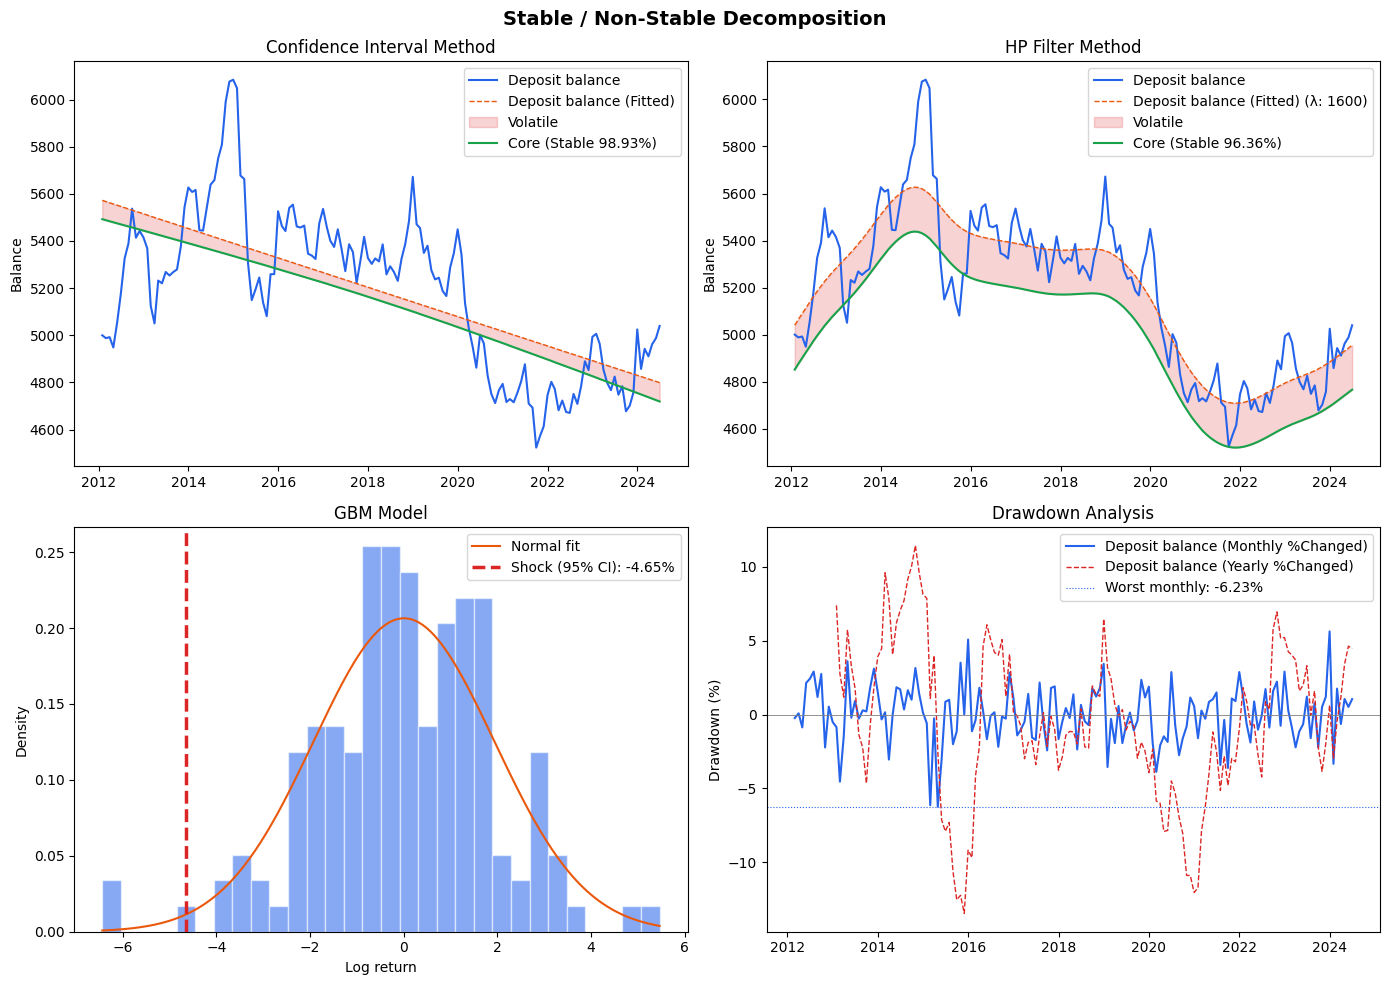

In [10]:
# Plot visualise all methods
plot_stable_results(
    balance = balance,
    ci_result = ci_result,
    hp_result = hp_result,
    dd_monthly = dd_monthly,
    dd_yearly = dd_yearly,
    gbm_result = gbm_result
)